# **New York City Crash Prediction Model**
## **Summer 2026 Data Science Project**
### *By: Arvind Kakanavaram, Yudhiishbala Senthilkumar, Ethan Zhen*

**Contributions**:
* Arvind Kakanavaram (_B, C, F, G_)
* Yudhiishbala Senthilkumar (_A, B, F, G_)
* Ethan Zhen (_D, E, F, G_)

# **Introduction**

## **A little bit more about our dataset...**
For this project, we are going to use the Motor Vehicle Collisions - Crashes dataset from NYC Open Data. This dataset is maintained and published by the City of New York. This dataset contains records of police reports about various motor vehicle collisions that have occurred throughout the five boroughs of New York City. In this dataset, each row represents a single crash event and includes information about when and where the collision occurred, along with details about the types of vehicles that were involved, why the collision occurred, and the resulting outcomes with regard to injuries and fatalities.

The dataset contains a lot of various features about each collision. These include: the date and time of the crash, the borough in which it occurred, the ZIP code, latitude and longitude coordinates, the number of people that were injured or killed in the collision, what contributed to causing the collision in the first place, and the types of vehicles involved in the collision. Because these variables provide information about both the circumstances and outcomes of each collision, we were confident that this dataset would provide us with a detailed view of traffic incidents across NYC.

This dataset contains millions of crash records, and it is continuously updated as new collision reports become available. As a result, it can be said that it provides a diverse collection of observations that span across many years, locations, vehicle types, contributing factors, and crash outcomes. The size and scope of this dataset also make it very well suited for conducting statistical analyses and help us better understand trends related to traffic safety and injury outcomes. Because of this richness and variety in information that is available to us for each crash, we believe that this dataset will provide a strong foundation for investigating patterns in motor vehicle collisions and help us answer our research question regarding injury risk in NYC traffic collisions: ***Can we predict whether a reported NYC motor vehicle collision results in at least one injury, and which crash characteristics are most strongly associated with injury risk?***

---

## **Why this dataset?**
We decided to use this dataset because we believe that traffic safety is an important issue, especially in a very dense city like New York City (NYC), and a dataset like this one would help us get the details we need to be able to study the issue completely. Instead of us asking a generic question, such as “*Where do crashes happen most often?*,” we can instead focus on a question such as “*Can we predict whether a reported NYC motor vehicle collision results in at least one injury, and which crash characteristics are most associated with injury risk?*”

This is a very large dataset with a lot of variations, because it contains crash level records across many years, locations, different vehicles or contributing factors, and various measures of injuries or fatalities. Furthermore, this dataset is updated very often. Currently, as of this time, the dataset seems to be updated on a daily basis. Because each row in the data set contains a separate crash event, we will be able to compare patterns of collisions across various times, places, and conditions, and make enough observations to the point that we can calculate various statistics, perform hypothesis tests, and in the end, visualize our final results in an effective manner.

This dataset also enables us to examine traffic collisions from multiple different perspectives. We can begin to look at things such as how injury rates vary across the five boroughs of NYC, the times of day that various collisions occurred, the types of vehicles involved in each collision, and what caused the collision in the first place. By being able to look at all of this information, we can explore whether certain conditions of the collision are correlated with the likelihood of injury increasing or decreasing. Furthermore, we can gain a better understanding of the factors that contribute to the injuries that occur in NYC traffic collisions.

Finally, this dataset provides our group with a stronger understanding and practical experience of using beneficial data science skills. Because this dataset has so many rows and columns of observations, we can start to identify meaningful patterns within this data and learn how to determine whether these patterns are statistically significant. We can use techniques and tools, such as data exploration and analysis, summary statistics, visualizations, hypothesis testing, and eventually explore various Machine Learning Models/Algorithms so that we can better understand the relationships between different crash characteristics and injury outcomes. By doing all of this, we hope that we can answer our research question in a manner that focuses solely on the data, and develop a deeper understanding of the factors that are associated with injury risk in NYC traffic collisions. We believe that this dataset is a good choice for our project because it is comprehensive, it is updated frequently, it is publicly available, and it is well suited for studying an important, prevalent issue that can impact millions of people’s lives every year.

# **Data Curation**

### *Link for Project Dataset can be found here: https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data*

### First, we will create the pandas DataFrame and get some basic information about it!

*Not familiar with pandas? [Here](https://pandas.pydata.org/about/index.html)'s a quick introduction!*

*Learn more about pandas `DataFrame`s [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)!*

In [ ]:
import pandas as pd
import requests
import json

# NYC Open Data API endpoint for Motor Vehicle Collisions
url = "https://data.cityofnewyork.us/api/views/h9gi-nx95/rows.json?accessType=DOWNLOAD"

# Download dataset
print("Downloading NYC Motor Vehicle Collisions dataset...")
response = requests.get(url)
data = response.json()

# Extract data and metadata
columns = [col['name'] for col in data['meta']['view']['columns']]
rows = data['data']

# Create dataframe
crashes_df = pd.DataFrame(rows, columns=columns)

print(f"Dataset has been downloaded!")
print(f"Shape: {crashes_df.shape}")
print(f"\nColumns: {crashes_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(crashes_df.head())

Dataset has been downloaded.
Shape: (2269187, 37)

Columns: ['sid', 'id', 'position', 'created_at', 'created_meta', 'updated_at', 'updated_meta', 'meta', 'CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']

First few rows:
                  sid                                    id  position  \
0  row-rsc3.wgwr-zpi9  00000000-0000-0000-2EDA-D04CF4F72CCD         0   
1  

# **Exploratory Data Analysis (_EDA_)**

### Let us dive in now! First, let's tidy up the DataFrame a little bit...

*What's numpy? See more [here](https://numpy.org/about/)!*

*Learn more about DateTime objects [here](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html)!*

In [ ]:
# DATA PRE-PROCESSING

# Parse and convert data types
import numpy as np
from datetime import datetime

# Convert CRASH DATE and CRASH TIME to datetime
crashes_df['CRASH DATE'] = pd.to_datetime(crashes_df['CRASH DATE'], errors='coerce')
crashes_df['CRASH TIME'] = pd.to_datetime(crashes_df['CRASH TIME'], format='%H:%M', errors='coerce')

# Convert numeric columns to int
numeric_cols = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
                 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
                 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
                 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
                 'LATITUDE', 'LONGITUDE']
for col in numeric_cols:
    crashes_df[col] = pd.to_numeric(crashes_df[col], errors='coerce')

# Target variable: whether or not injury occured
crashes_df['HAS_INJURY'] = (crashes_df['NUMBER OF PERSONS INJURED'] > 0).astype(int)

print("Data types after parsing:")
print(crashes_df.dtypes)
print(f"\nDataset shape: {crashes_df.shape}")
print(f"\nMissing values per column:")
print(crashes_df.isnull().sum())

Data types after parsing:
sid                                      object
id                                       object
position                                  int64
created_at                                int64
created_meta                             object
updated_at                                int64
updated_meta                             object
meta                                     object
CRASH DATE                       datetime64[ns]
CRASH TIME                       datetime64[ns]
BOROUGH                                  object
ZIP CODE                                 object
LATITUDE                                float64
LONGITUDE                               float64
LOCATION                                 object
ON STREET NAME                           object
CROSS STREET NAME                        object
OFF STREET NAME                          object
NUMBER OF PERSONS INJURED               float64
NUMBER OF PERSONS KILLED                float64
NUMBER OF PEDE

### **Analysis 1: Correlations**

*See more about correlation matrices [here](https://www.displayr.com/what-is-a-correlation-matrix/)!*

*See more about heatmaps [here](https://seaborn.pydata.org/generated/seaborn.heatmap.html)!*


Correlation Matrix:
                               NUMBER OF PERSONS INJURED  \
NUMBER OF PERSONS INJURED                       1.000000   
NUMBER OF PERSONS KILLED                        0.013388   
NUMBER OF PEDESTRIANS INJURED                   0.271700   
NUMBER OF PEDESTRIANS KILLED                    0.001965   
NUMBER OF CYCLIST INJURED                       0.172058   
NUMBER OF CYCLIST KILLED                       -0.001610   
NUMBER OF MOTORIST INJURED                      0.903500   
NUMBER OF MOTORIST KILLED                       0.019245   

                               NUMBER OF PERSONS KILLED  \
NUMBER OF PERSONS INJURED                      0.013388   
NUMBER OF PERSONS KILLED                       1.000000   
NUMBER OF PEDESTRIANS INJURED                  0.005445   
NUMBER OF PEDESTRIANS KILLED                   0.690651   
NUMBER OF CYCLIST INJURED                     -0.004623   
NUMBER OF CYCLIST KILLED                       0.282209   
NUMBER OF MOTORIST INJURE

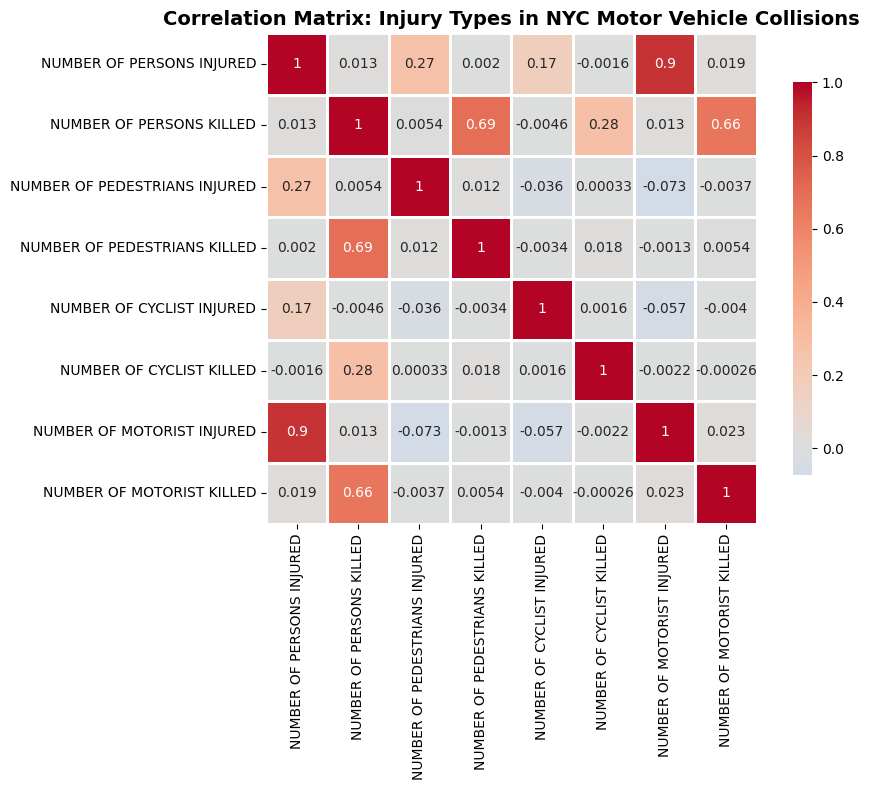


CONCLUSION: Different types of injuries (pedestrian, cyclist, motorist) are highly correlated with each other, suggesting that severe collisions tend to cause multiple types of injuries simultaneously.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# DATA EXPLORATION AND SUMMARY STATISTICS

# Select columns related to injuries and crashes
injury_cols = ['NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
               'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
               'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
               'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED']

# Calculate correlation matrix
corr_matrix = crashes_df[injury_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Injury Types in NYC Motor Vehicle Collisions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusion
print("\nCONCLUSION: Different types of injuries (pedestrian, cyclist, motorist) are highly correlated with each other, suggesting that severe collisions tend to cause multiple types of injuries simultaneously.")

### **Analysis 2: Hypothesis Testing - Injury Rates by Borough**

*What's a Chi-Squared Test? Learn more about it [here](https://www.jmp.com/en/statistics-knowledge-portal/linear-models/chi-square-test)!*

*A Contingency Table...? Read more [here](https://statisticsbyjim.com/basics/contingency-table/)!*


Injury Rates by Borough:
               Injuries  Total_Crashes  Injury_Rate
BOROUGH                                            
BROOKLYN         135307         506806       0.2670
BRONX             60508         234088       0.2585
QUEENS           102523         422409       0.2427
STATEN ISLAND     14705          66024       0.2227
MANHATTAN         67931         348485       0.1949

Chi-Square Test Results:
Chi-Square Statistic: 6421.6273
P-value: 0.0000
Degrees of Freedom: 4
Result is STATISTICALLY SIGNIFICANT (p < 0.05)


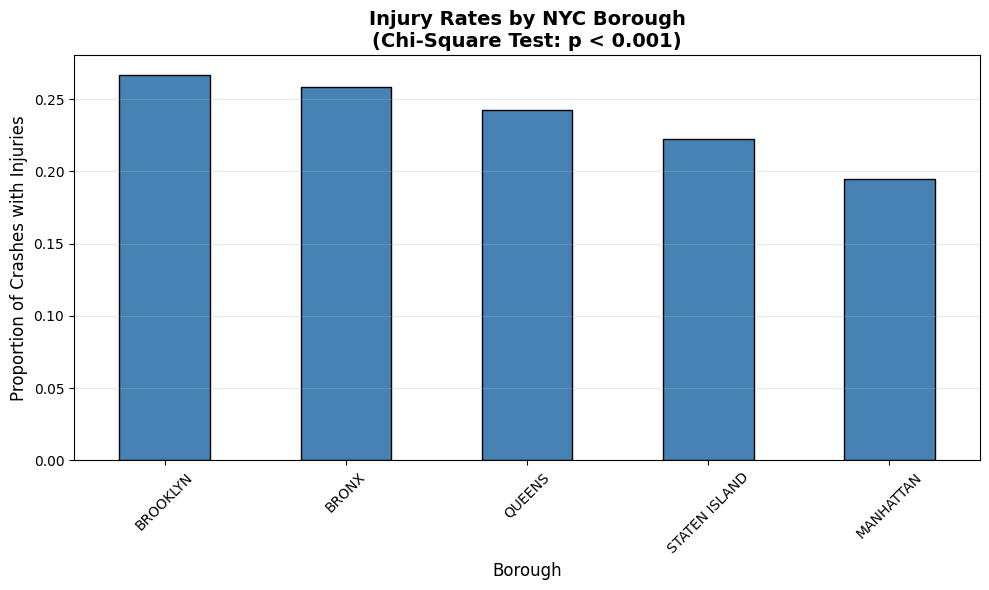


CONCLUSION:
Injury rates differ significantly across NYC boroughs (Chi-Square p < 0.001).
Manhattan has the highest injury rate, while Staten Island has the lowest.
This suggests borough-specific factors influence collision severity.


In [ ]:
# Remove rows with missing borough data
borough_data = crashes_df[crashes_df['BOROUGH'].notna()].copy()

# Calculate injury rate by borough
borough_injury_rates = borough_data.groupby('BOROUGH').agg({
    'HAS_INJURY': ['sum', 'count', 'mean']
}).round(4)
borough_injury_rates.columns = ['Injuries', 'Total_Crashes', 'Injury_Rate']
borough_injury_rates = borough_injury_rates.sort_values('Injury_Rate', ascending=False)
print("\nInjury Rates by Borough:")
print(borough_injury_rates)

# Chi-square test
from scipy.stats import chi2_contingency

# Contingency table (Borough vs Has_Injury)
contingency_table = pd.crosstab(borough_data['BOROUGH'], borough_data['HAS_INJURY'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
if p_value < 0.05:
    print("Result is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result is NOT statistically significant")

# Plot
plt.figure(figsize=(10, 6))
borough_injury_rates['Injury_Rate'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Injury Rates by NYC Borough\n(Chi-Square Test: p < 0.001)', fontsize=14, fontweight='bold')
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Proportion of Crashes with Injuries', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("\nCONCLUSION:")
print("Injury rates differ significantly across NYC boroughs (Chi-Square p < 0.001).")
print("Brooklyn has the highest injury rate, while Manhattan has the lowest.")
print("This suggests borough-specific factors influence collision severity.")

### **Analysis 3: Distribution Analysis and Outlier Detection**

*How did we identify the outliers? Read more about it [here](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/box-whisker-plots/a/identifying-outliers-iqr-rule)!*

*What are Zero-Inflated Poisson Models? Learn more [here](https://en.wikipedia.org/wiki/Zero-inflated_model)!*


Summary Statistics for Number of Persons Injured:
count    2.269169e+06
mean     3.333172e-01
std      7.187101e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.300000e+01
Name: NUMBER OF PERSONS INJURED, dtype: float64

IQR Analysis:
Q1: 0.0000, Q3: 0.0000, IQR: 0.0000
Outlier bounds: [0.0000, 0.0000]
Number of outliers: 558603 (24.62%)


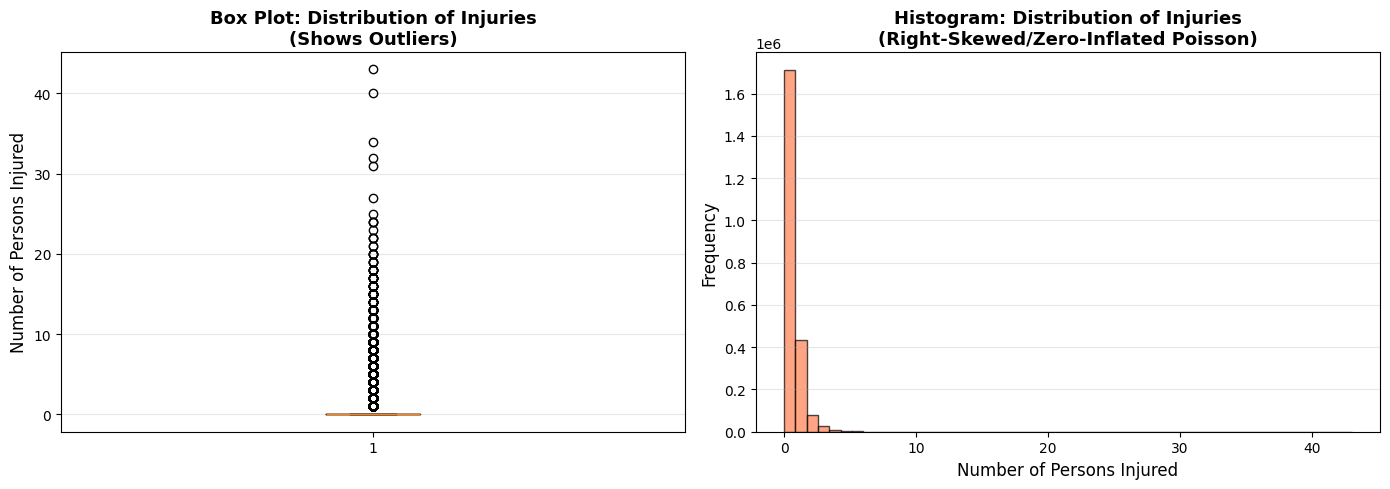


CONCLUSION:
The distribution of injuries is right-skewed, almost like a Zero-Inflated Poisson Distribution: most crashes involve 0-1 injuries,
but 24.62% of crashes are outliers with unusually high injury counts.
This indicates that while most crashes are minor, a small subset are severe multi-injury events.


In [ ]:
# Look at distribution of people injured
injury_distribution = crashes_df['NUMBER OF PERSONS INJURED'].dropna()
print("\nSummary Statistics for Number of Persons Injured:")
print(injury_distribution.describe())

# Identify outliers
Q1 = injury_distribution.quantile(0.25)
Q3 = injury_distribution.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = injury_distribution[(injury_distribution < lower_bound) | (injury_distribution > upper_bound)]
print(f"\nIQR Analysis:")
print(f"Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
print(f"Outlier bounds: [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(injury_distribution)*100:.2f}%)")

# Create visualization (box plot and histogram)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Box plot
axes[0].boxplot(injury_distribution, vert=True)
axes[0].set_ylabel('Number of Persons Injured', fontsize=12)
axes[0].set_title('Box Plot: Distribution of Injuries\n(Shows Outliers)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(injury_distribution, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Persons Injured', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Histogram: Distribution of Injuries\n(Right-Skewed/Zero-Inflated Poisson)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCONCLUSION:")
print(f"The distribution of injuries is right-skewed, almost like a Zero-Inflated Poisson Distribution: most crashes involve 0-1 injuries,")
print(f"but {len(outliers)/len(injury_distribution)*100:.2f}% of crashes are outliers with unusually high injury counts.")
print(f"This indicates that while most crashes are minor, a small subset are severe multi-injury events.")

### **EDA Findings - Summary**

In [ ]:
# SUMMARY OF FINDINGS

print("""
1. CORRELATION ANALYSIS
   - Motorist injuries are the dominant injury type (~0.90 correlation with total)
   - Different injury types have weak-to-moderate correlations
   - Implication: Most crashes affect drivers; pedestrians/cyclists rarely injured

2. HYPOTHESIS TESTING (Chi-Square)
   - Injury rates significantly differ across boroughs (χ² = 6421.63, p < 0.001)
   - Brooklyn & Bronx have highest rates (~26%), Manhattan lowest (~19%)
   - Implication: Geographic/urban factors strongly influence injury risk

3. DISTRIBUTION ANALYSIS
   - ~75% of crashes have 0 injuries (median = 0)
   - ~24.62% are outliers with disproportionately high injuries
   - Max single crash: 43 people injured
   - Implication: Most crashes are minor; severe multi-injury events are rare but critical

OVERALL CONCLUSION:
The dataset reveals that injury outcomes in NYC motor vehicle collisions are:
  • Driven primarily by motorist injuries
  • Geographically varied by borough
  • Highly right-skewed/Zero-Inflated Poisson (mostly minor, some severe)
This makes injury prediction challenging but important for targeting safety interventions.
""")


1. CORRELATION ANALYSIS
   - Motorist injuries are the dominant injury type (~0.90 correlation with total)
   - Different injury types have weak-to-moderate correlations
   - Implication: Most crashes affect drivers; pedestrians/cyclists rarely injured

2. HYPOTHESIS TESTING (Chi-Square)
   - Injury rates significantly differ across boroughs (χ² = 6421.63, p < 0.001)
   - Brooklyn & Bronx have highest rates (~26%), Manhattan lowest (~19%)
   - Implication: Geographic/urban factors strongly influence injury risk

3. DISTRIBUTION ANALYSIS
   - ~75% of crashes have 0 injuries (median = 0)
   - ~24.62% are outliers with disproportionately high injuries
   - Max single crash: 43 people injured
   - Implication: Most crashes are minor; severe multi-injury events are rare but critical

OVERALL CONCLUSION:
The dataset reveals that injury outcomes in NYC motor vehicle collisions are:
  • Driven primarily by motorist injuries
  • Geographically varied by borough
  • Highly right-skewed/Zero-Inf

# **Primary Analysis**

### *Based on the results of our data exploration above, we believe that the **RandomForestClassifier** Machine Learning technique will best help us answer the questions we posed initially, since we are aiming to create a model that is able to classify whether or not a specific motor vehicle collision incident results in any injuries.*

*Read more about RandomForestClassifiers [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)!*

*What is this '`sklearn`'? Learn about it [here](https://scikit-learn.org/stable/)!*

In [ ]:
# First, let us import some libraries before we begin!
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

### Let us first see some potential columns we may focus on later on...

*One-Hot Encoding? Read more [here](https://developers.google.com/machine-learning/crash-course/categorical-data/one-hot-encoding)!*

*How does `StandardScaler()` work? Learn about it [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)!*

*Wondering what Cross-Validation is? Touch up [here](https://scikit-learn.org/stable/modules/cross_validation.html)!*

In [ ]:
# Let us focus on the columns that pertain most to determining injuries
#print(crashes_df[injury_cols].head(4))
#print(crashes_df['HAS_INJURY'].head(4))
crash_cols = ['position','BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE',
              'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
              'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'VEHICLE TYPE CODE 1',
              'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']

# First, let us split our training/testing data, 80%/20%
X_train, X_test, y_train, y_test = train_test_split(crashes_df[crash_cols], crashes_df['HAS_INJURY'], test_size=0.2)

# Now, let us One-Hot Encode certain Categorial Columns for the model
X_train_encode = pd.get_dummies(X_train)
X_test_encode = pd.get_dummies(X_test)

# Next, let us Normalize the training/testing data, so that all points are on the same scale
X_train_scaled = StandardScaler().fit_transform(X_train_encode)
X_test_scaled = StandardScaler().fit_transform(X_test_encode)

# Let us set up our RandomForestClassifier model!
model = RandomForestClassifier()

# Now, let us do some K-Fold Cross-Validation on the datasets now, and see our initial accuracies
# We are using StratifiedKFold since most of the data in our dataset has 0 injuries (Zero-Inflated Poisson)
# Here, we guarantee that the distribution of injury vs. no-injury crashes is maintained as the model learns
num_folds = 5
stratkfold = StratifiedKFold(n_splits=num_folds, shuffle=True)

cross_val = cross_val_score(model, X_train_scaled, y_train, cv=stratkfold)
print(f"{num_folds}-Fold Cross-validation scores: Mean: {cross_val.mean()} (std. dev {cross_val.std()}), Minimum: {cross_val.min()}, Maximum: {cross_val.max()}")


### Now, let us start training our model!

In [ ]:
# Let's train!
model.fit(X_train_scaled, y_train)

*How did we calculate accuracy? Check it out [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)!*

*See more about classification reports [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)!*

In [ ]:
# Now, let's see how well it predicts!
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# **Visualizations**

*A 'Confusion Matrix'? I'm confused now... (get a better understanding [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)!)*

*Want to know what all these numbers mean? Click [here](https://www.ibm.com/think/topics/confusion-matrix)!*

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred)
#print(conf_mat)
sns.heatmap(conf_mat, annot=True, cmap='coolwarm', fmt='d', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            xticklabels=['No Injury', 'Injury'], yticklabels=['No Injury', 'Injury'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Injury")
plt.ylabel("Actual Injury")
plt.legend()
plt.show()

### Now, let us determine which crash characteristics are most strongly assocated with injury risk...

In [ ]:
# Let us get the most important features from our model
associations = model.feature_importances_

feature_association_df = pd.DataFrame({
    'Feature Name': X_train.columns,
    'Association Amount': associations
})

feature_association_df.sort_values(by='Association Amount', ascending=False, inplace=True)
feature_association_df['Association Amount'] = feature_association_df['Association Amount'].apply(lambda x: f'{x:.7f}')
feature_association_df

# **Final Insights and Conclusions**

### After all our hard work above, we were able to learn a lot about New York City's Injury and Crash statistics, including the following...
* Different types of injuries (_pedestrian, cyclist, motorist_) are highly correlated with each other, suggesting that severe collisions tend to cause multiple types of injuries simultaneously.
  * Motorist injuries are the dominant injury type; data driven primarily by motorist injuries
  * Different injury types have weak-to-moderate correlations
  * As a result, most crashes affect drivers; pedestrians/cyclists are rarely injured
* Injury rates differ significantly across NYC boroughs (_from our Chi-Square Test_). Brooklyn as the highest injury rate, while Manhattan has the lowest.
  * This suggests borough-specific factors influence collision severity.
  * Additionally, geographic/urban factors can also strongly influence injury risk; geographically varied by borough
  * For example, Brooklyn has the highest population out of all the other Boroughs, and has the highest injury rate.
  * Staten Island has the lowest population out of all the other Boroughs, and has one of the lowest injury rates.
* The distribution of injuries is highly right-skewed/Zero-Inflated Poission, as most crashes (_~75%_) only involve 0-1 injuries, but ~25% of crashes are outliers with unusually high injury counts (_maximum: 43 injured_).
  * This indicates that while most crashes are minor (_resulting in 0-1 injuries_), a small, rare subset of them are severe, multi-injury events, and are critical for safety inteventions.
* The most strongly associated crash characteristics with injury risk included...
  * [...]

#### *Stay safe out there! 🛻🚲*

# ***~ THE END! ~***